In [2]:
import muspan as ms
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle
import networkx as nx
import cv2

from roifile import roiread
from persim import plot_diagrams

print("Packages loaded successfully!")

Packages loaded successfully!


In [3]:
def cycle_intensity(cycles):
    #cycle strength is cycle death time
    cycles = [i[1] for i in cycles]
    return cycles

def edge_strength(components,b1=5,b2=100,plot=False):
    #edge strength is component birth time
    edges = [i[0] for i in components]
    return edges

def component_intensity(components,d1=150,plot=False):
    #component intensity is component death time
    components = [i[1] for i in components]
    return components

def hole_strength(cycles):
    #hole strength is cycle birth time
    cycles = [i[0] for i in cycles]
    return cycles



In [4]:
def basic_filtering(components,cycles, min_lifespan=30,upper=200,plot=False):

    print(f"Number of components before: {len(components)}")
    comp_filter = [i[1]-i[0]>=min_lifespan for i in components] #filter min lifespan
    comp_filter2 = [i[0]<=upper for i in components] #filter below birth limit
    components = components[np.logical_and(comp_filter,comp_filter2)]

    print(f"Number of components after filtering: {len(components)}")


    print(f"Number of cycles before: {len(cycles)}")
    cycle_filter = [i[1]-i[0]>=min_lifespan for i in cycles] #filter min lifespan
    cycle_filter2 = [i[0]<=upper for i in cycles] #filter below birth limit
    cycles = cycles[np.logical_and(cycle_filter,cycle_filter2)]
    print(f"Number of cycles after filtering: {len(cycles)}")

    if plot:
        if len(components)>0:
            plot_diagrams([components,cycles], show=True)
    return([components,cycles])


Stage HH3, n=1, image is 702 wide and 584 tall
Number of components before: 1171
Number of components after filtering: 295
Number of cycles before: 487
Number of cycles after filtering: 92


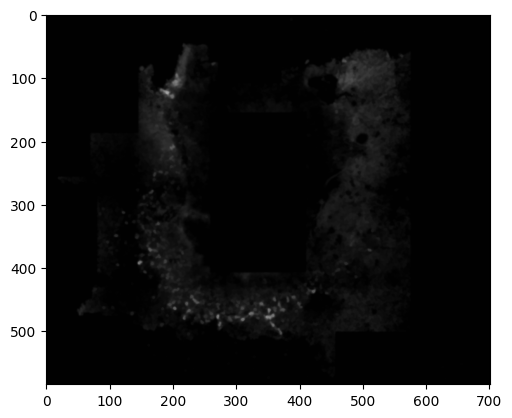

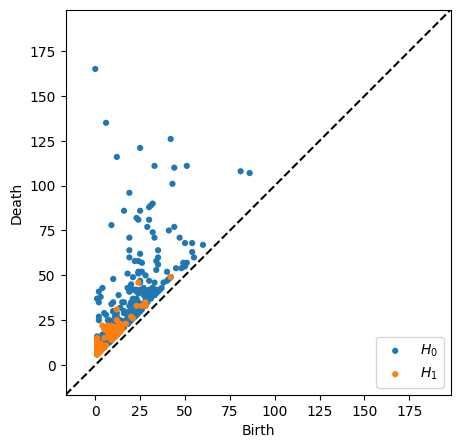

Stage HH3, n=2, image is 702 wide and 608 tall
Number of components before: 10
Number of components after filtering: 4
Number of cycles before: 0
Number of cycles after filtering: 0


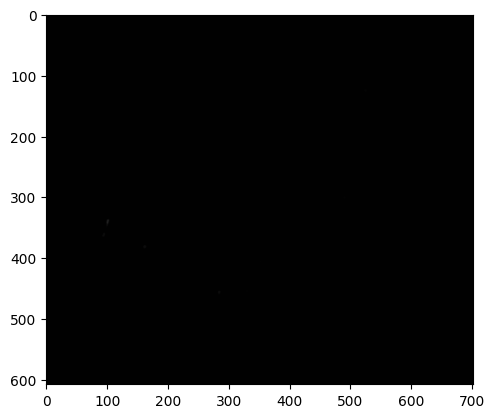

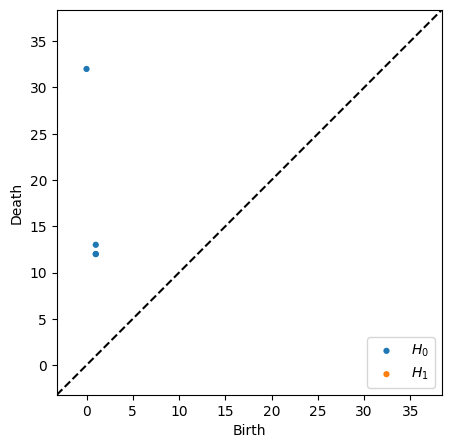

Stage HH4, n=1, image is 645 wide and 800 tall
Number of components before: 1881
Number of components after filtering: 595
Number of cycles before: 912
Number of cycles after filtering: 195


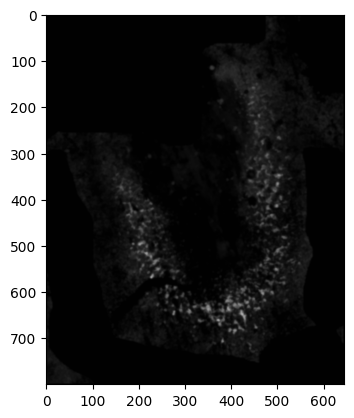

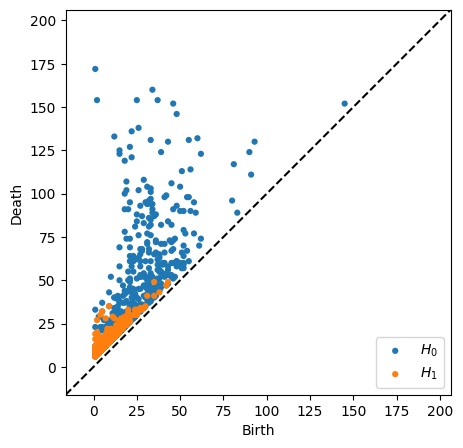

Stage HH4, n=2, image is 702 wide and 565 tall
Number of components before: 1789
Number of components after filtering: 436
Number of cycles before: 513
Number of cycles after filtering: 60


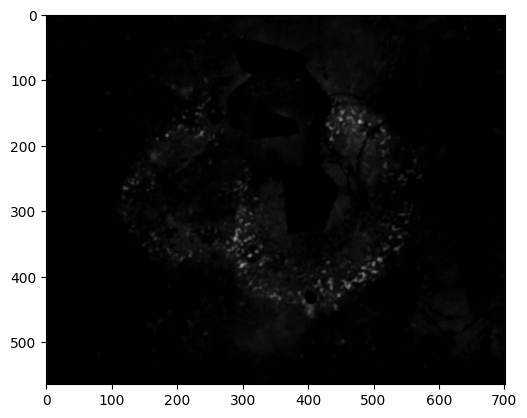

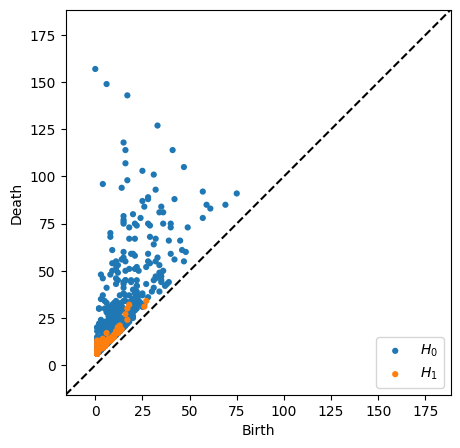

Stage HH4, n=3, image is 544 wide and 800 tall
Number of components before: 1850
Number of components after filtering: 423
Number of cycles before: 679
Number of cycles after filtering: 94


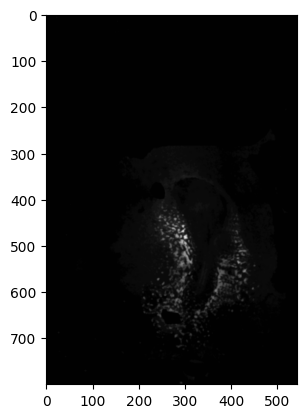

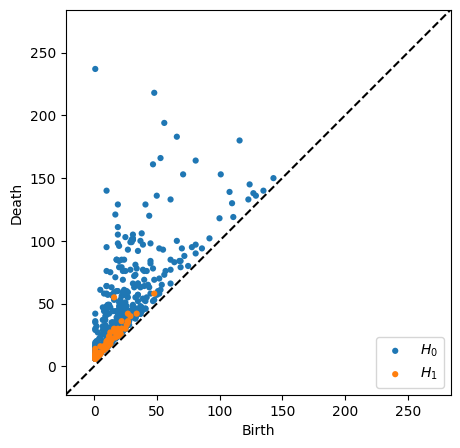

Stage HH4, n=4, image is 515 wide and 800 tall
Number of components before: 1345
Number of components after filtering: 519
Number of cycles before: 547
Number of cycles after filtering: 154


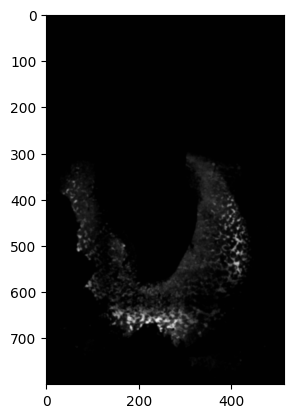

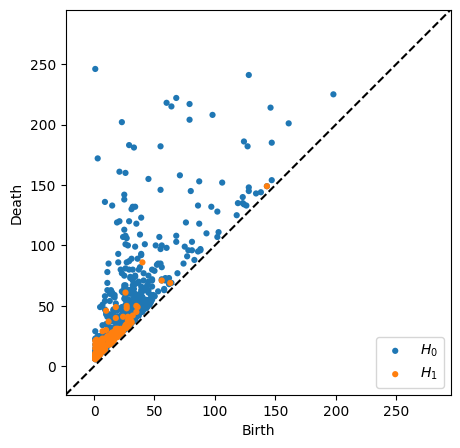

Stage HH5, n=1, image is 702 wide and 772 tall
Number of components before: 1974
Number of components after filtering: 800
Number of cycles before: 924
Number of cycles after filtering: 293


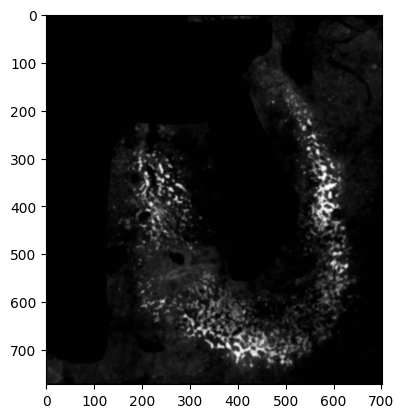

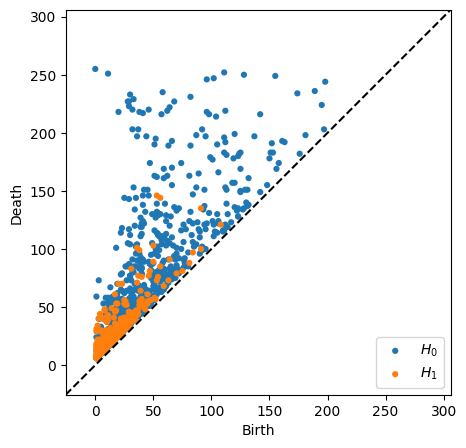

Stage HH5, n=2, image is 702 wide and 779 tall
Number of components before: 1171
Number of components after filtering: 637
Number of cycles before: 453
Number of cycles after filtering: 232


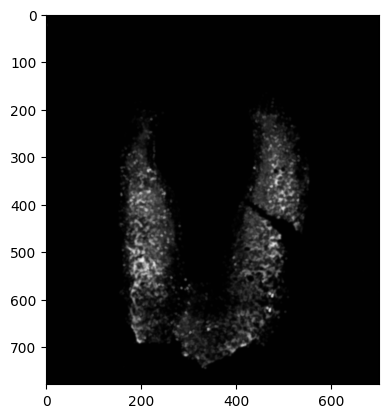

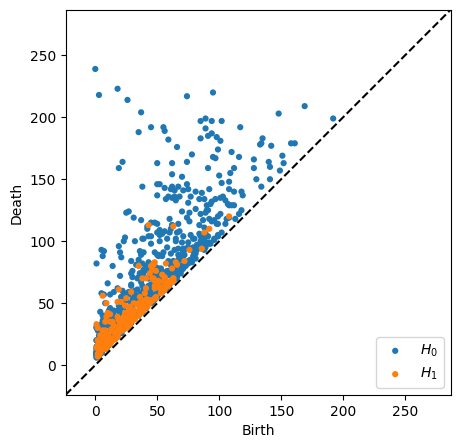

Stage HH6, n=1, image is 682 wide and 800 tall
Number of components before: 2281
Number of components after filtering: 794
Number of cycles before: 893
Number of cycles after filtering: 310


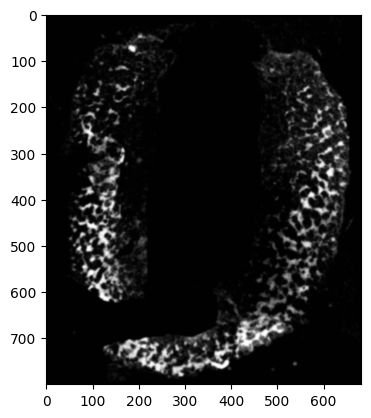

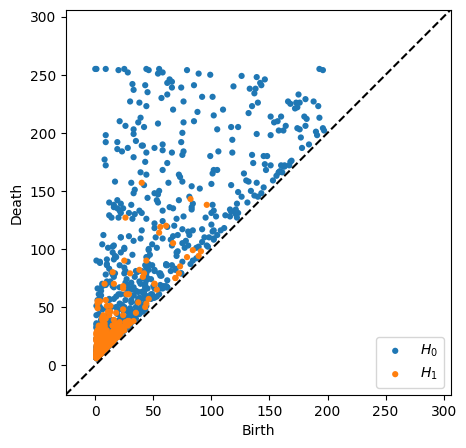

Stage HH6, n=2, image is 702 wide and 697 tall
Number of components before: 2151
Number of components after filtering: 693
Number of cycles before: 697
Number of cycles after filtering: 417


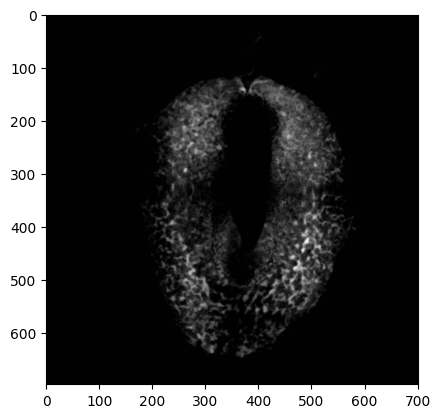

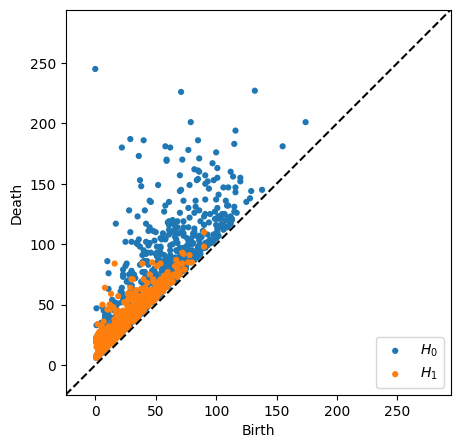

Stage HH6, n=3, image is 702 wide and 777 tall
Number of components before: 914
Number of components after filtering: 363
Number of cycles before: 147
Number of cycles after filtering: 57


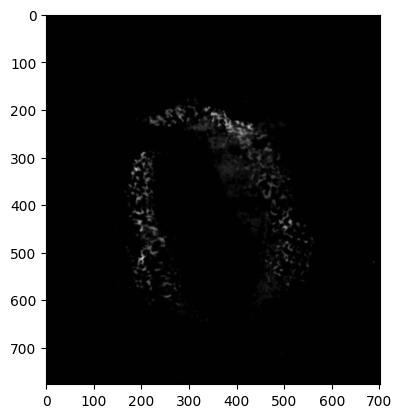

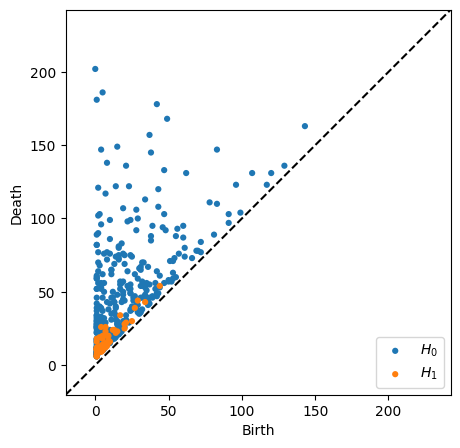

Stage HH7, n=1, image is 685 wide and 800 tall
Number of components before: 701
Number of components after filtering: 273
Number of cycles before: 180
Number of cycles after filtering: 54


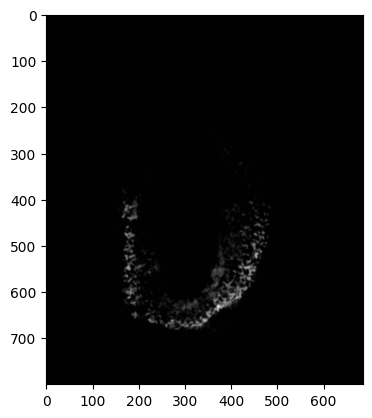

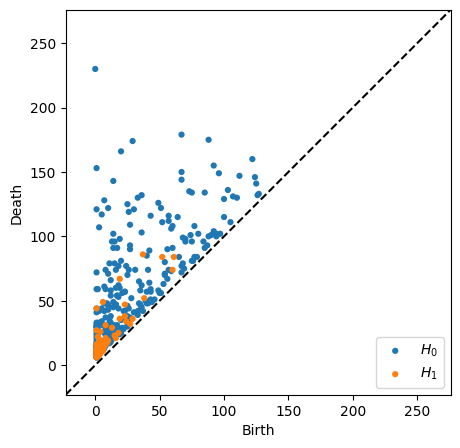

Stage HH7, n=2, image is 702 wide and 759 tall
Number of components before: 1187
Number of components after filtering: 426
Number of cycles before: 367
Number of cycles after filtering: 181


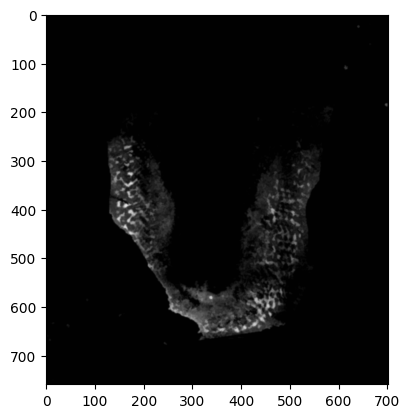

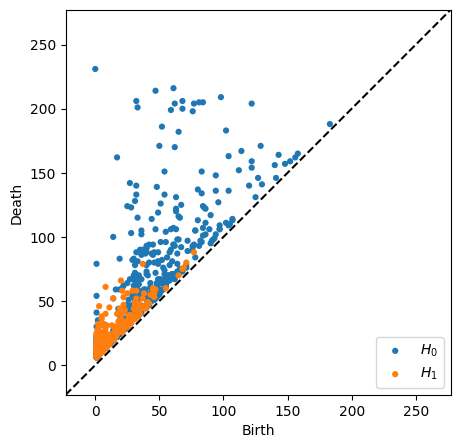

Stage HH8, n=1, image is 644 wide and 800 tall
Number of components before: 2227
Number of components after filtering: 853
Number of cycles before: 779
Number of cycles after filtering: 247


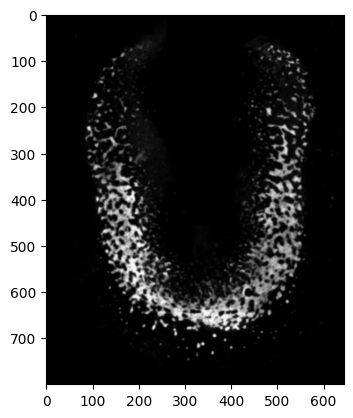

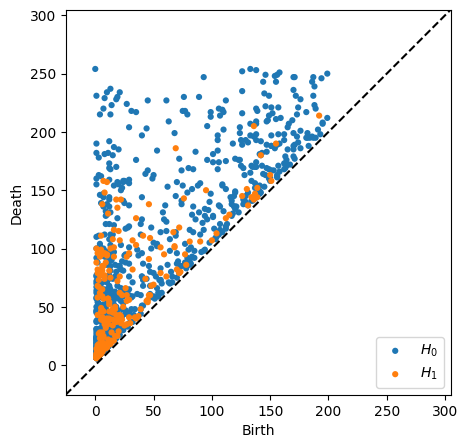

Stage HH8, n=2, image is 687 wide and 800 tall
Number of components before: 2092
Number of components after filtering: 560
Number of cycles before: 756
Number of cycles after filtering: 147


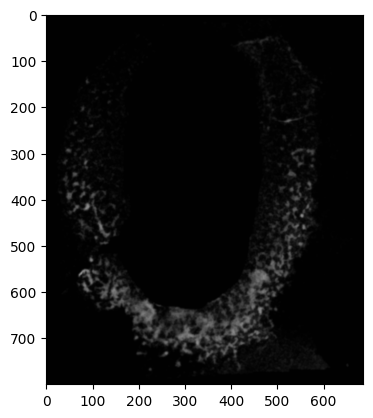

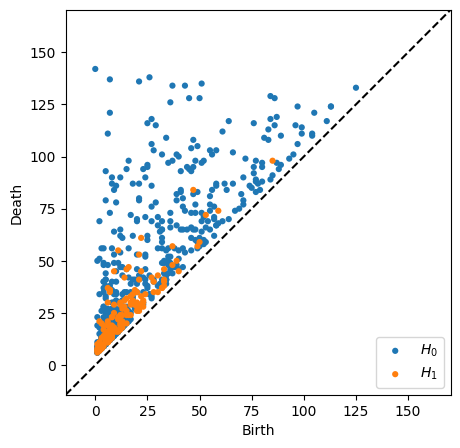

Stage HH9, n=1, image is 575 wide and 800 tall
Number of components before: 3872
Number of components after filtering: 711
Number of cycles before: 1538
Number of cycles after filtering: 247


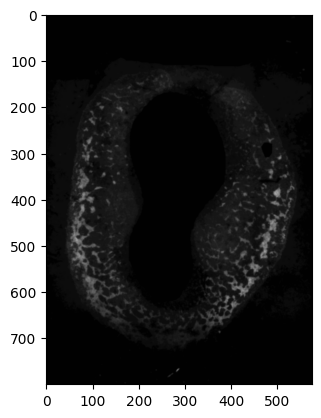

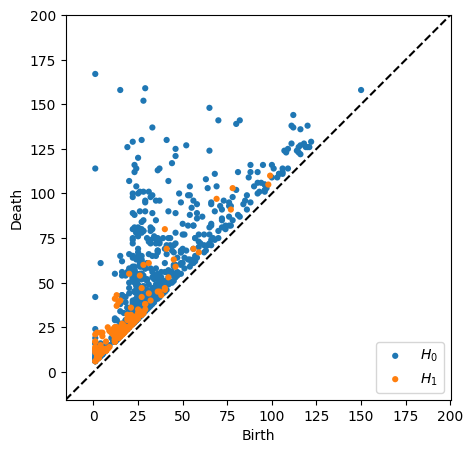

Stage HH9, n=2, image is 702 wide and 796 tall
Number of components before: 2377
Number of components after filtering: 668
Number of cycles before: 1178
Number of cycles after filtering: 410


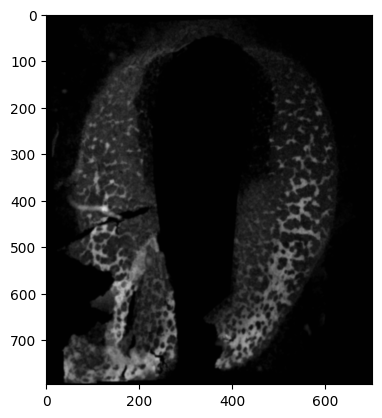

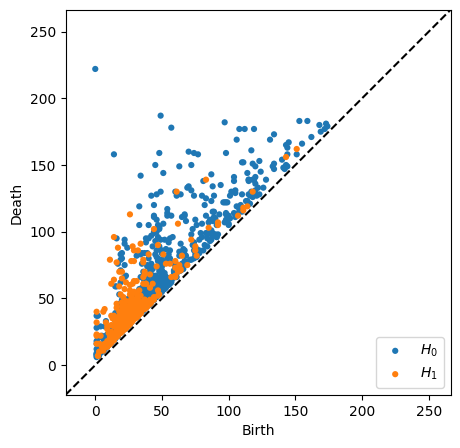

Stage HH9, n=3, image is 591 wide and 800 tall
Number of components before: 2445
Number of components after filtering: 784
Number of cycles before: 847
Number of cycles after filtering: 199


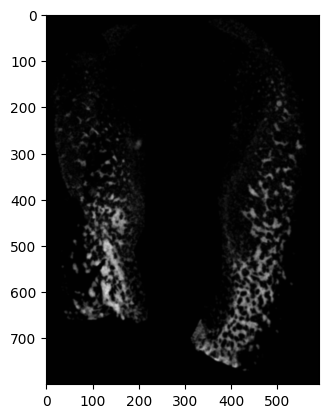

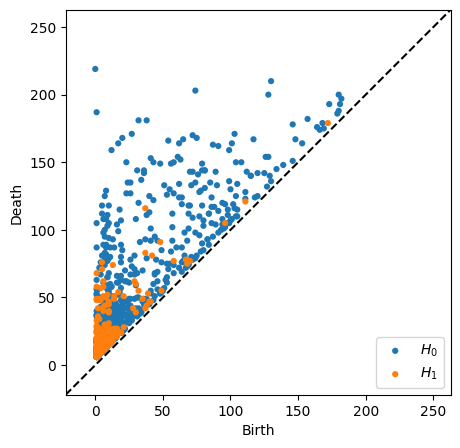

Stage HH9, n=4, image is 702 wide and 736 tall
Number of components before: 2696
Number of components after filtering: 566
Number of cycles before: 727
Number of cycles after filtering: 293


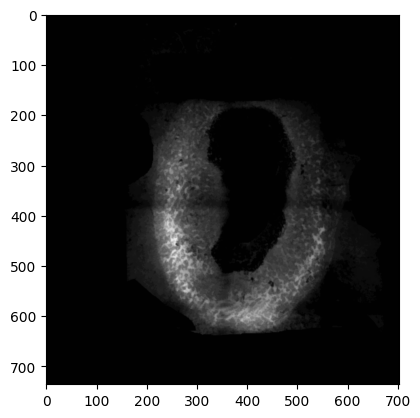

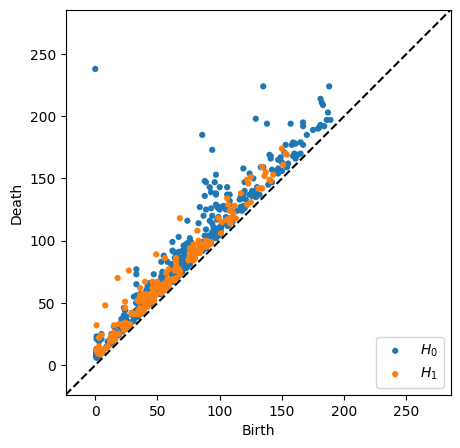

Stage HH10, n=1, image is 642 wide and 800 tall
Number of components before: 2759
Number of components after filtering: 655
Number of cycles before: 1130
Number of cycles after filtering: 202


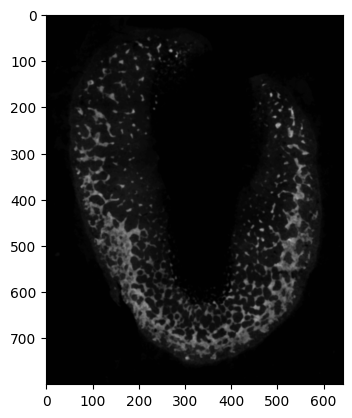

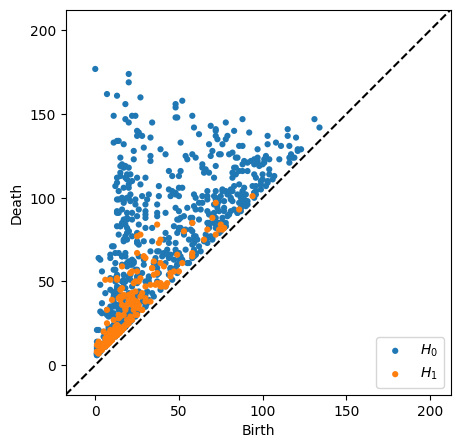

Stage HH10, n=2, image is 702 wide and 754 tall
Number of components before: 1501
Number of components after filtering: 400
Number of cycles before: 431
Number of cycles after filtering: 228


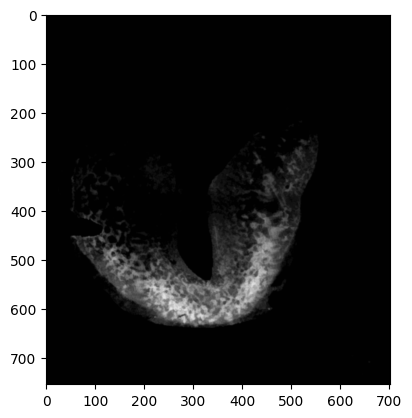

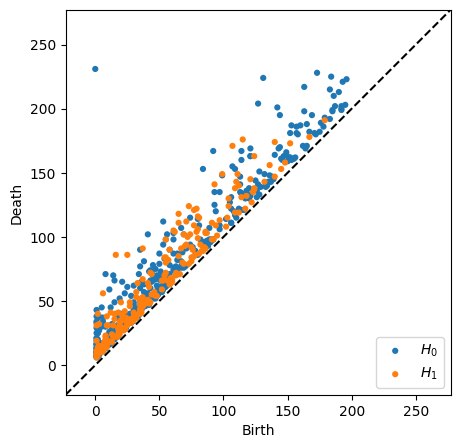

Stage HH10, n=3, image is 702 wide and 780 tall
Number of components before: 2797
Number of components after filtering: 834
Number of cycles before: 918
Number of cycles after filtering: 278


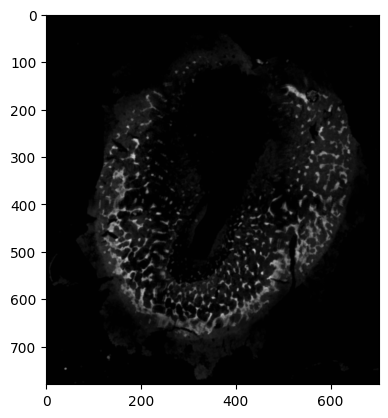

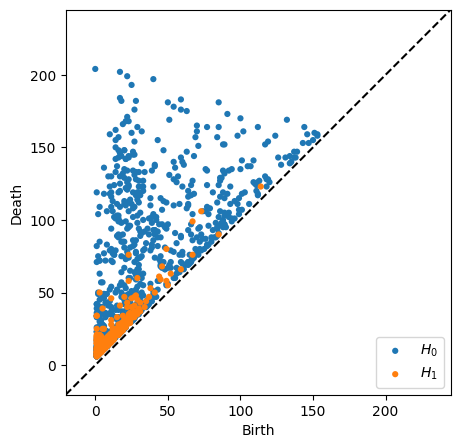

Stage HH11, n=1, image is 702 wide and 791 tall
Number of components before: 3165
Number of components after filtering: 1045
Number of cycles before: 1453
Number of cycles after filtering: 630


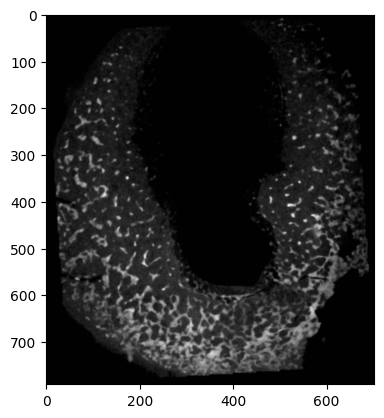

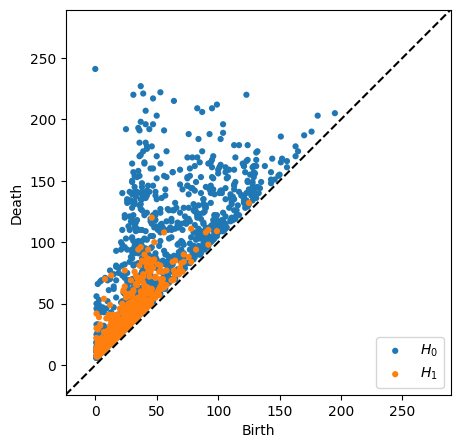

Stage HH11, n=2, image is 575 wide and 800 tall
Number of components before: 3109
Number of components after filtering: 748
Number of cycles before: 1137
Number of cycles after filtering: 265


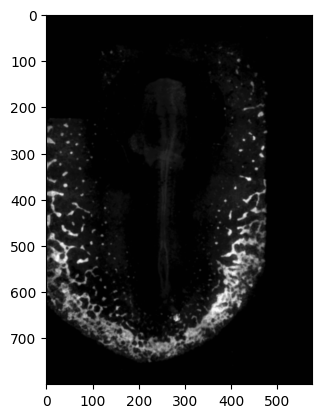

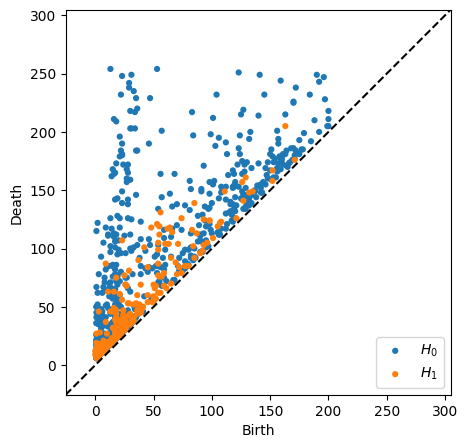

Stage HH12, n=1, image is 504 wide and 800 tall
Number of components before: 2991
Number of components after filtering: 839
Number of cycles before: 1262
Number of cycles after filtering: 267


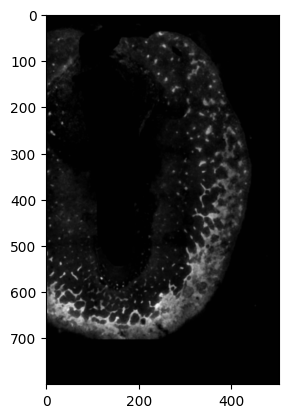

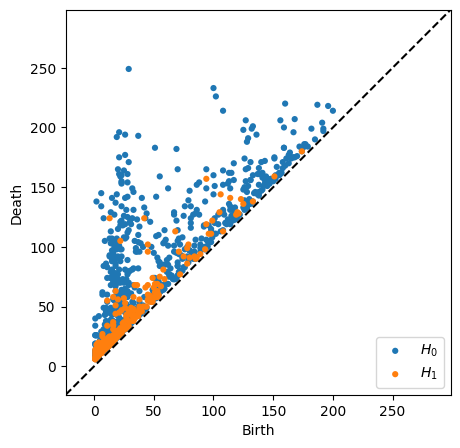

Stage HH12, n=2, image is 702 wide and 710 tall
Number of components before: 5281
Number of components after filtering: 947
Number of cycles before: 1468
Number of cycles after filtering: 402


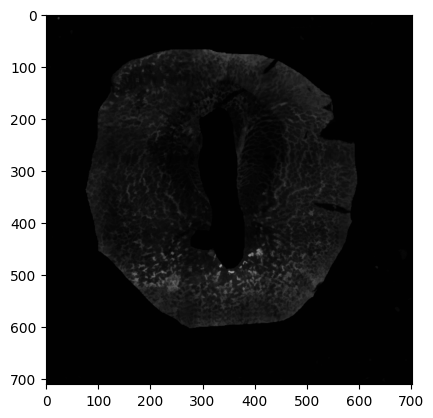

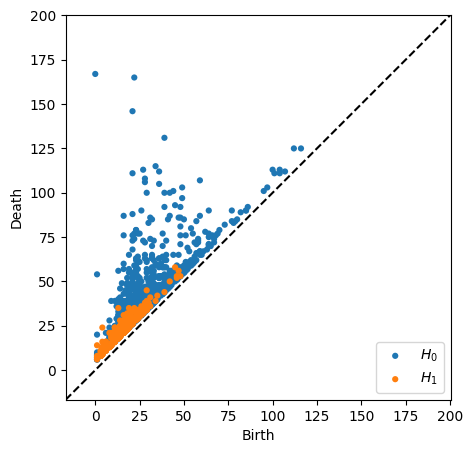

Stage HH13, n=1, image is 633 wide and 800 tall
Number of components before: 6424
Number of components after filtering: 843
Number of cycles before: 2551
Number of cycles after filtering: 484


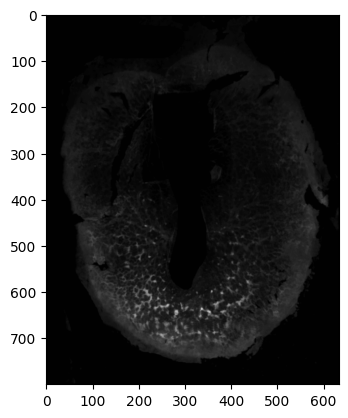

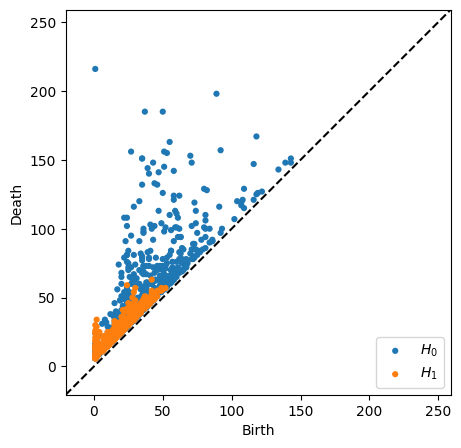

Stage HH13, n=2, image is 702 wide and 731 tall
Number of components before: 3330
Number of components after filtering: 858
Number of cycles before: 970
Number of cycles after filtering: 551


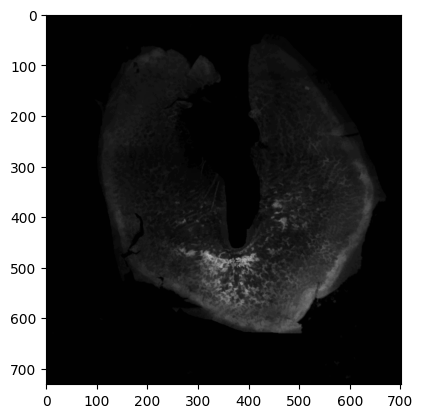

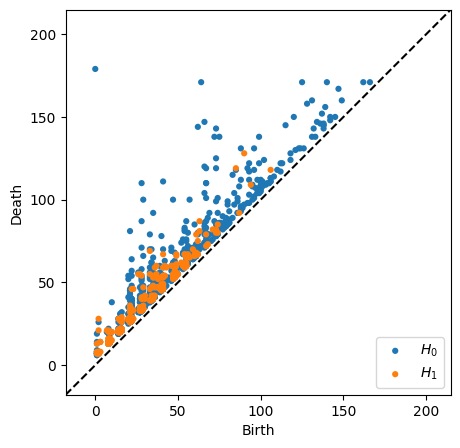

In [5]:

stages = [3,4,5,6,7,8,9,10,11,12,13]
new_width = 500
max_n=5
background_colour = "black"

num_components = pd.DataFrame(index=stages,columns=[1,2,3,4,5])
num_cycles = pd.DataFrame(index=stages,columns=[1,2,3,4,5])

components_intensities = []
cycles_intensities = []

edges_strengths = []
holes_strengths = []

vectors = []

particle_size=10


for i in range(len(stages)):
    stage = stages[i]
    n=1
    n_maxxed = False #repeat until files cannot be found
    while not n_maxxed:
        #image = cv2.imread(f'data/ph_test_cycles.png') #test image
        image = cv2.imread(f'data/PH_histograms/{particle_size}um/hh{stage}_n{n}_Cleaned_{particle_size}um.png')
        
        if image is None: #file not found
            n_maxxed=True
        else:

            height = len(image)
            width = len(image[0])

            if height > 800:
                new_height = 800
                new_width = int(800/height * width)
                image = cv2.resize(image, (new_width,new_height)) #downscale to not crash python
                
            plt.imshow(image)
            
            
            if background_colour == "white": #invert image so we can filter in right direction (PH filters from black to white)
                image = 255-image

            grey_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
            print(f"Stage HH{stage}, n={n}, image is {len(image[0])} wide and {len(image)} tall")




            #run PH
            result = ms.topology.level_set_filtration(grey_image) 
            
            fig,ax=plt.subplots(figsize=(5,5))

            cycles = result["dgms"][0] #reverse the cycle and components (because we filtered black to white instead of white to black: hacky workaround)
            components = result["dgms"][1]

            cycles = cycles[[ r[1]<999 for r in cycles]] #remove the infinite cycle generated
            #print(components)
            #print("\n")
            #print(cycles)



            #appending data structures
            [components,cycles] = basic_filtering(components,cycles,plot=True,min_lifespan=5)
            #filtered_persistence = {"dgms":[components,cycles]}
            #ms.visualise.barcode(filtered_persistence)

            num_components.loc[stage,n] = len(components)
            num_cycles.loc[stage,n] = len(cycles)

            components_intensities.append({"Stage": stage, "n": n, "components intensities": component_intensity(components)})
            cycles_intensities.append({"Stage": stage, "n": n, "cycles intensities": cycle_intensity(cycles)})

            edges_strengths.append({"Stage": stage, "n": n, "edges strengths": edge_strength(components)})
            holes_strengths.append({"Stage": stage, "n": n, "holes strengths": hole_strength(cycles)})

            #if len(components)>0:
            vectorised_ph,feature_names = ms.topology.vectorise_persistence(result, method='statistics')
            vectors.append({"Stage": stage, "n": n, "vectors": vectorised_ph})
            
            n=n+1


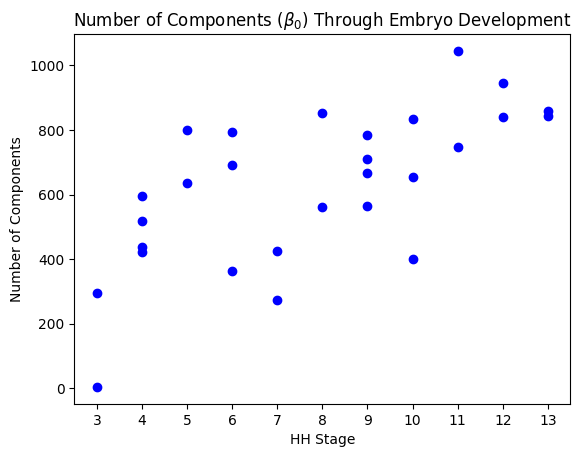

In [6]:

plt.plot(num_components.index,num_components,'o',color="blue")
plt.xlabel("HH Stage")
plt.ylabel("Number of Components")
plt.title(f"Number of Components ($\\beta_0$) Through Embryo Development")
plt.xticks(stages) # Ensures your X-axis only shows the actual stage numbers
plt.show()

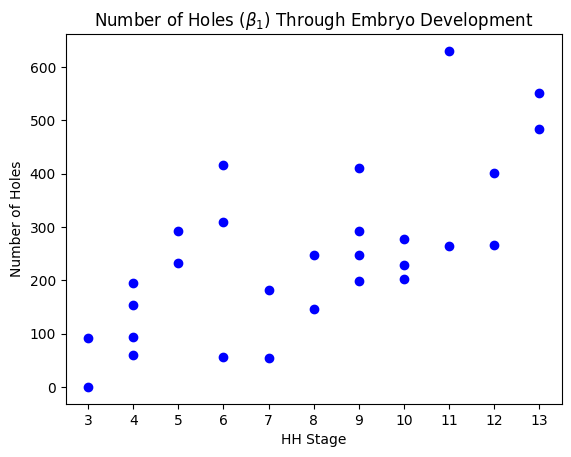

In [7]:

plt.plot(num_components.index,num_cycles,'o',color="blue")
plt.xlabel("HH Stage")
plt.ylabel("Number of Holes")
plt.title(f"Number of Holes ($\\beta_1$) Through Embryo Development")
plt.xticks(stages) # Ensures your X-axis only shows the actual stage numbers
plt.show()

In [8]:
def plot_iqr(feature_list,stages,label,title,yax):
    medians = []
    lower_errors = []
    upper_errors = []
    
    df=pd.DataFrame(feature_list)
    df_exploded = df.explode(label).dropna(subset=[label])

    for stage in stages:
        stage_data = df_exploded[df_exploded["Stage"]==stage][label]
        if len(stage_data)>0:

            med = np.median(stage_data)
            medians.append(med)

            lower_errors.append(med-np.percentile(stage_data,25))
            upper_errors.append(np.percentile(stage_data,75)-med)
        else:
            medians.append(0)
            lower_errors.append(0)
            upper_errors.append(0)

    plt.errorbar(stages,medians,yerr=[lower_errors,upper_errors],linewidth=2.5,capsize=4,capthick=2.5)
    plt.xlabel("HH Stage")
    plt.xticks(stages)
    plt.ylabel(yax)
    plt.title(f"{title} Through Embryo Development")
        




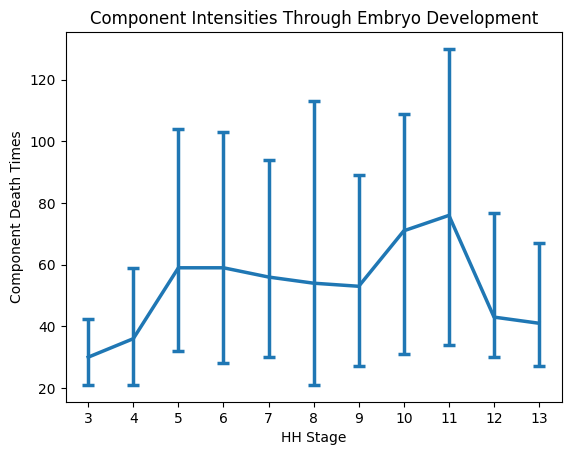

In [9]:
plot_iqr(components_intensities,stages,"components intensities","Component Intensities","Component Death Times")

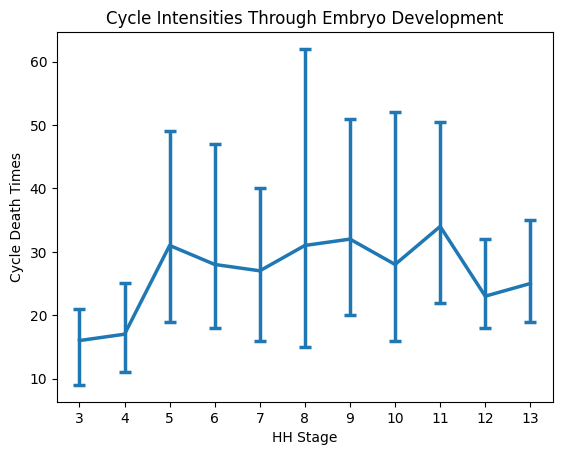

In [10]:
plot_iqr(cycles_intensities,stages,"cycles intensities","Cycle Intensities","Cycle Death Times")

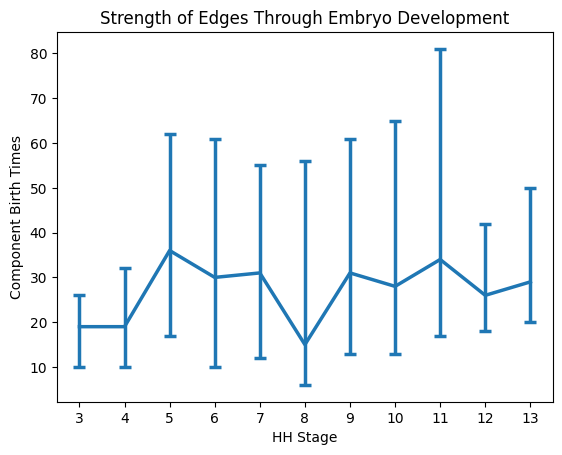

In [11]:
plot_iqr(edges_strengths,stages,"edges strengths","Strength of Edges","Component Birth Times")

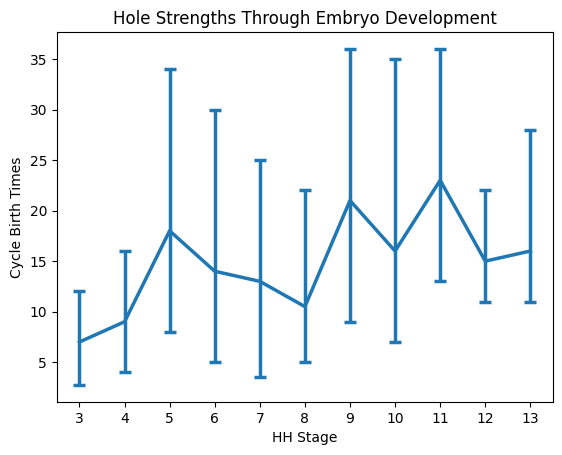

In [12]:
plot_iqr(holes_strengths,stages,"holes strengths","Hole Strengths","Cycle Birth Times")

Text(0.5, 1.0, 'PCA of Vectorised Persistence Diagrams')

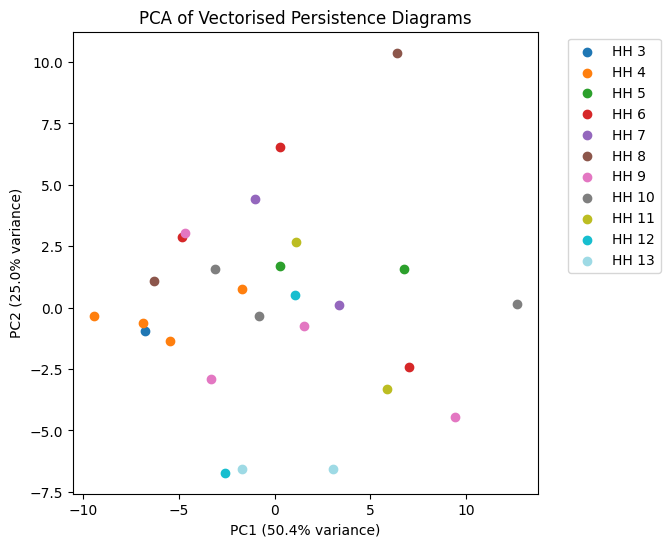

In [13]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.cm as cm
from sklearn.preprocessing import StandardScaler

vec=pd.DataFrame(vectors)

# 1. Create a True/False mask: True if the vector has NO NaNs
# .apply() runs this quick check on every single row in the "vectors" column
valid_mask = vec["vectors"].apply(lambda x: not np.isnan(x).any())

# 2. Overwrite vec to only keep the rows where the mask is True
vec = vec[valid_mask]


#gets the vector data as a list of lists
vecs_only = np.vstack(vec["vectors"]).tolist()

#standardisation
scaler = StandardScaler()
vecs_scaled = scaler.fit_transform(vecs_only)

# Perform PCA to reduce the dimensionality to 2 components
pca = PCA(n_components=2)
pca_result = pca.fit_transform(vecs_scaled)


# Plot the PCA result
fig, ax = plt.subplots(figsize=(6, 6))
n=0
cmap = cm.tab20(np.linspace(0, 1, len(stages)))

for i in range(len(stages)):
    stage = stages[i]
    pca_subset_stages = pca_result[vec["Stage"] == stage] #gets all embryos for the right stage
    
    ax.scatter(pca_subset_stages[:,0], pca_subset_stages[:,1], label=f'HH {stage}',color=cmap[i]) #plot pc1 and pc2

# Add labels and title to the plot
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('PCA of Vectorised Persistence Diagrams')

In [15]:
pc1 = pd.Series(index=feature_names,data=np.round(pca.components_[0],4))
print(f'PC1 represents {pca.explained_variance_ratio_[0]*100:.1f}% of variance')
print(f"Sum:{sum(pc1**2)}")
print(pc1)
print("\n")
print(pc1.sort_values(ascending=False).head())


pc2 = pd.Series(index=feature_names,data=np.round(pca.components_[1],4))
print(f'PC2 represents {pca.explained_variance_ratio_[1]*100:.1f}% of variance')
print(f"Sum:{sum(pc2**2)}")
print(pc2)
print("\n")
print(pc2.sort_values(ascending=False).head())

PC1 represents 50.4% of variance
Sum:1.00008847
H0 birth mean                   0.1693
H0 birth sd                     0.1549
H0 birth 10 percentile          0.0705
H0 birth 25 percentile          0.1237
H0 birth 50 percentile          0.1485
H0 birth 75 percentile          0.1586
H0 birth 90 percentile          0.1696
H0 death mean                   0.1792
H0 death sd                     0.1521
H0 death 10 percentile          0.1099
H0 death 25 percentile          0.1422
H0 death 50 percentile          0.1573
H0 death 75 percentile          0.1720
H0 death 90 percentile          0.1728
H0 midpoint mean                0.1753
H0 midpoint sd                  0.1541
H0 midpoint 10 percentile       0.1091
H0 midpoint 25 percentile       0.1395
H0 midpoint 50 percentile       0.1546
H0 midpoint 75 percentile       0.1682
H0 midpoint 90 percentile       0.1726
H0 persistence mean             0.1498
H0 persistence sd               0.1119
H0 persistence 10 percentile    0.0000
H0 persistence 2

In [13]:
def level_set_image(image,a):
    newim=np.copy(image)
    for i in range(len(image)):
        for j in range(len(image[0])):
            if image[i,j] >= 255-a:
                newim[i,j] = 255
    return newim